<h1 align=center> CRIBADO PRENATAL II </h1>

In [1]:
#Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier as RF


from Clases import *

In [2]:
Madre=pd.read_csv('./BBDD/Madre.csv',index_col=0)
T1=pd.read_csv('./BBDD/T1_MoM.csv',index_col=0)
T2=pd.read_csv('./BBDD/T2_MoM.csv',index_col=0)
TEST=pd.read_csv('./BBDD/TEST.csv',index_col=0)

<h1>PARTICIÓN T1</h1>

In [3]:
T1_X=T1.join(Madre.drop(columns="CLASE"),how="left")
T1_y=Madre.loc[T1.index,"CLASE"]

T2_X=T2.join(Madre.drop(columns="CLASE"),how="left")
T2_y=Madre.loc[T2.index,"CLASE"]

TEST_X=TEST.join(Madre.drop(columns="CLASE"),how="left")
TEST_y=Madre.loc[TEST.index,"CLASE"]

skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=777)

<h2> SAMPLERS</h2>

In [4]:
num_cols=["EDADmadre","TALLAmadre","PESOmadre"]
preprocessor=ColumnTransformer([
    ("standard",StandardScaler(),num_cols)],
                               verbose_feature_names_out=False,remainder="passthrough").set_output(transform="pandas")
T1_X_sc=preprocessor.fit_transform(T1_X)
#TEST_X_sc=preprocessor.transform(TEST_X)

# _________ MODELOS Y GRIDS___________
models={"NB":GaussianNB(),
       "SVC":SVC(gamma="scale",probability=True)}
param_spaces={
    "NB":None,
    "SVC": lambda trial: {"C":trial.suggest_float("C",0.001,50,log=True),
                         "kernel":(k:=trial.suggest_categorical("kernel",["rbf","linear"])),
                         **({"gamma": trial.suggest_float("gamma",1e-4,1,log=True)} if k=="rbf" else {})}
}

Samplers:   0%|          | 0/4 [00:00<?, ?it/s]

Models:   0%|          | 0/2 [00:00<?, ?it/s]

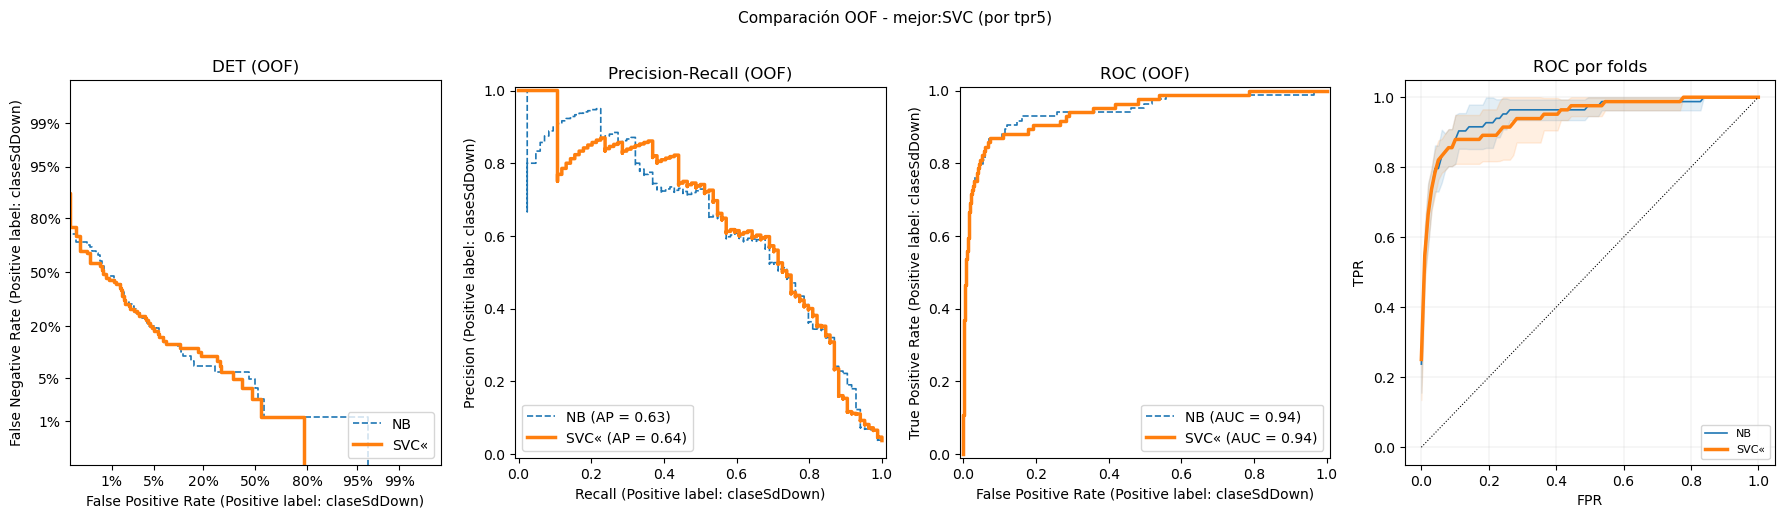


=== Métricas CV - ordenado por tpr5 ===
         sensitivity    specificity balanced_accuracy          gmean           tpr5
model                                                                              
SVC«   0.809 ± 0.053  0.947 ± 0.012     0.878 ± 0.029  0.875 ± 0.031  0.821 ± 0.063
NB     0.809 ± 0.053  0.951 ± 0.011     0.880 ± 0.030  0.877 ± 0.032  0.796 ± 0.074

 Modelo Seleccionado: SVC


Models:   0%|          | 0/2 [00:00<?, ?it/s]

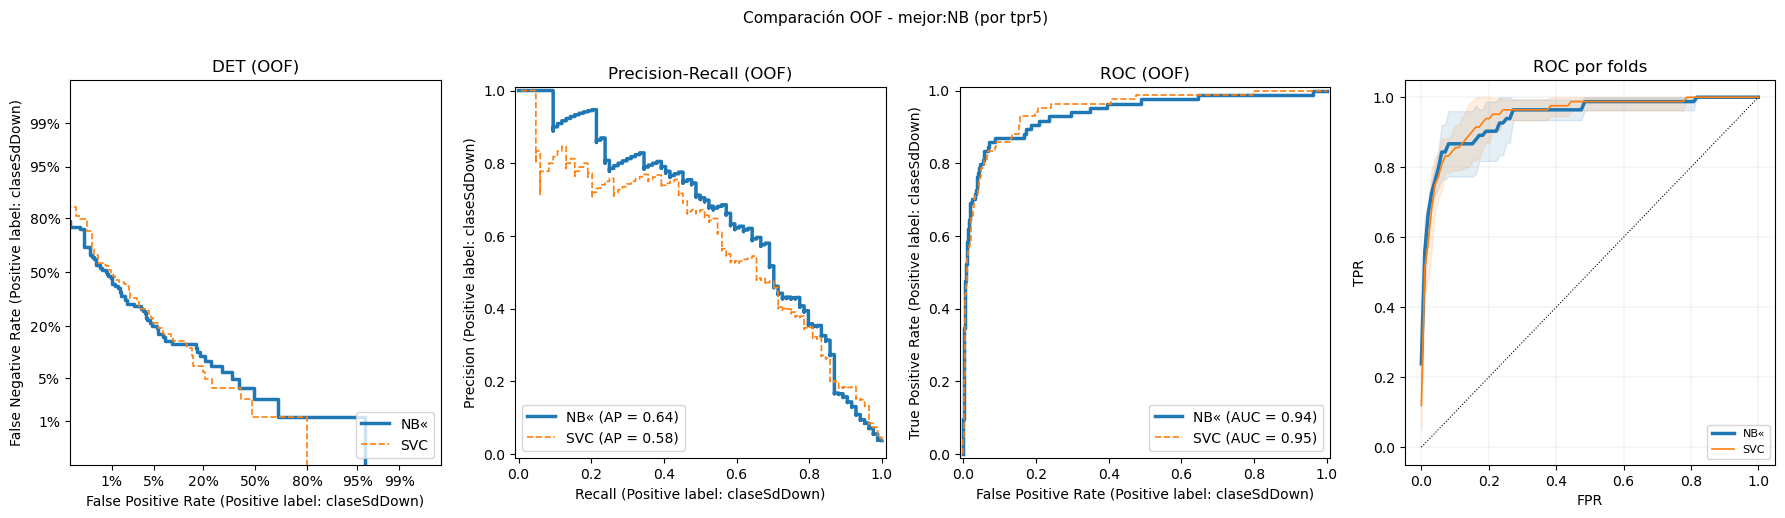


=== Métricas CV - ordenado por tpr5 ===
         sensitivity    specificity balanced_accuracy          gmean           tpr5
model                                                                              
NB«    0.785 ± 0.073  0.950 ± 0.015     0.867 ± 0.036  0.862 ± 0.040  0.796 ± 0.061
SVC    0.761 ± 0.076  0.952 ± 0.007     0.856 ± 0.039  0.850 ± 0.043  0.773 ± 0.070

 Modelo Seleccionado: NB


Models:   0%|          | 0/2 [00:00<?, ?it/s]

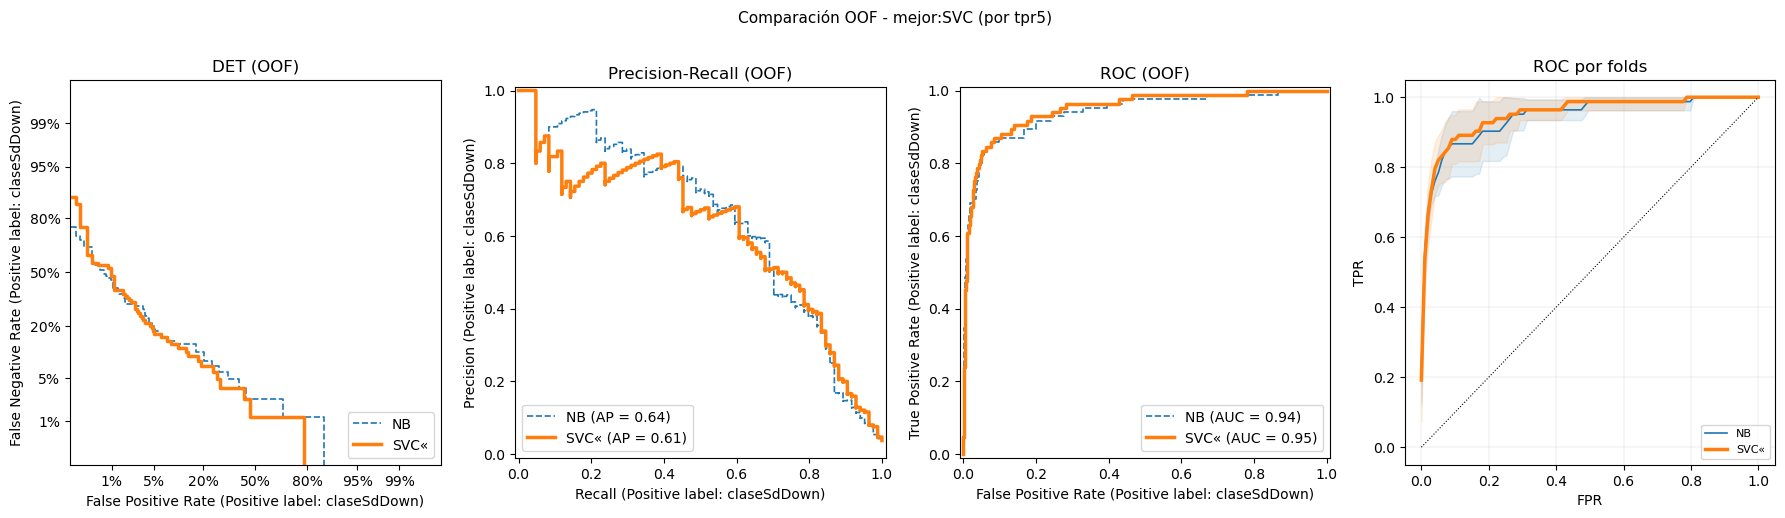


=== Métricas CV - ordenado por tpr5 ===
         sensitivity    specificity balanced_accuracy          gmean           tpr5
model                                                                              
SVC«   0.796 ± 0.074  0.952 ± 0.008     0.874 ± 0.038  0.870 ± 0.042  0.820 ± 0.080
NB     0.785 ± 0.084  0.951 ± 0.016     0.868 ± 0.041  0.862 ± 0.045  0.785 ± 0.073

 Modelo Seleccionado: SVC


Models:   0%|          | 0/2 [00:00<?, ?it/s]

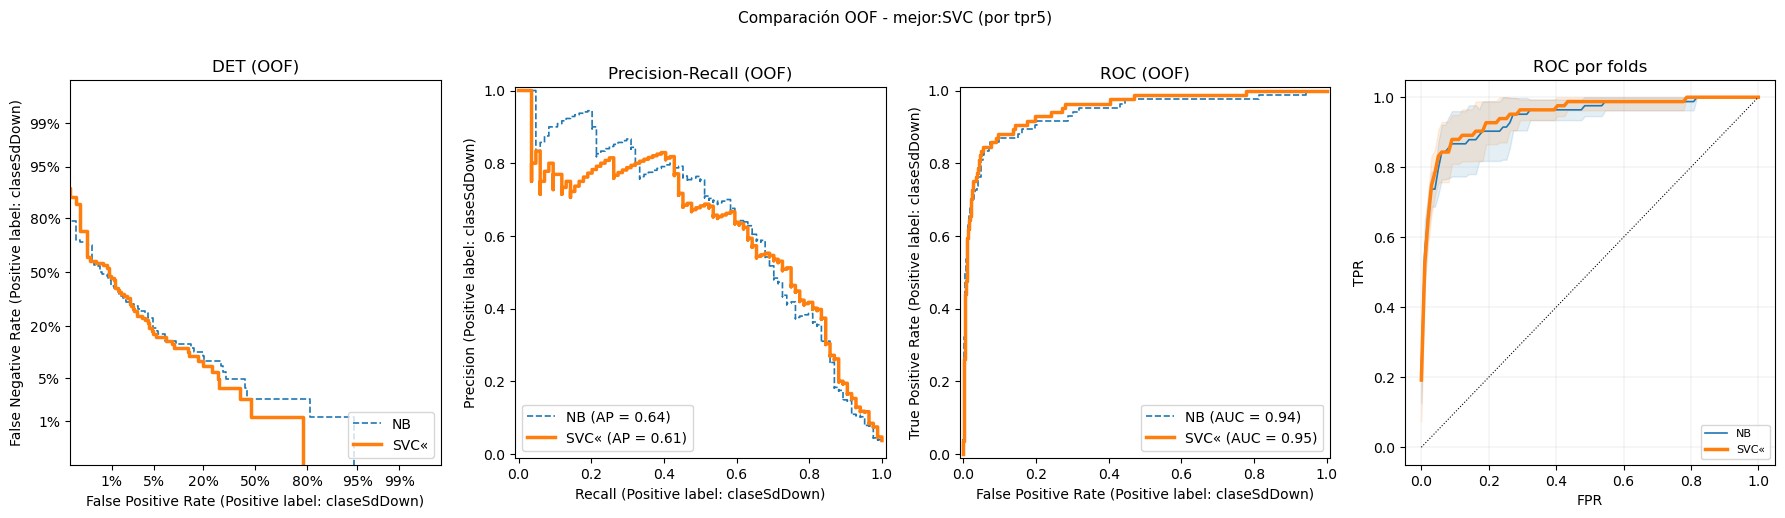


=== Métricas CV - ordenado por tpr5 ===
         sensitivity    specificity balanced_accuracy          gmean           tpr5
model                                                                              
SVC«   0.820 ± 0.099  0.951 ± 0.010     0.885 ± 0.050  0.882 ± 0.054  0.832 ± 0.084
NB     0.796 ± 0.094  0.948 ± 0.014     0.872 ± 0.046  0.868 ± 0.051  0.796 ± 0.085

 Modelo Seleccionado: SVC


In [6]:
sc=SamplerComparison(cv=skf,sampling_strategy=0.3)
df_comp=sc.compare(models,T1_X_sc,T1_y,grids=param_spaces)

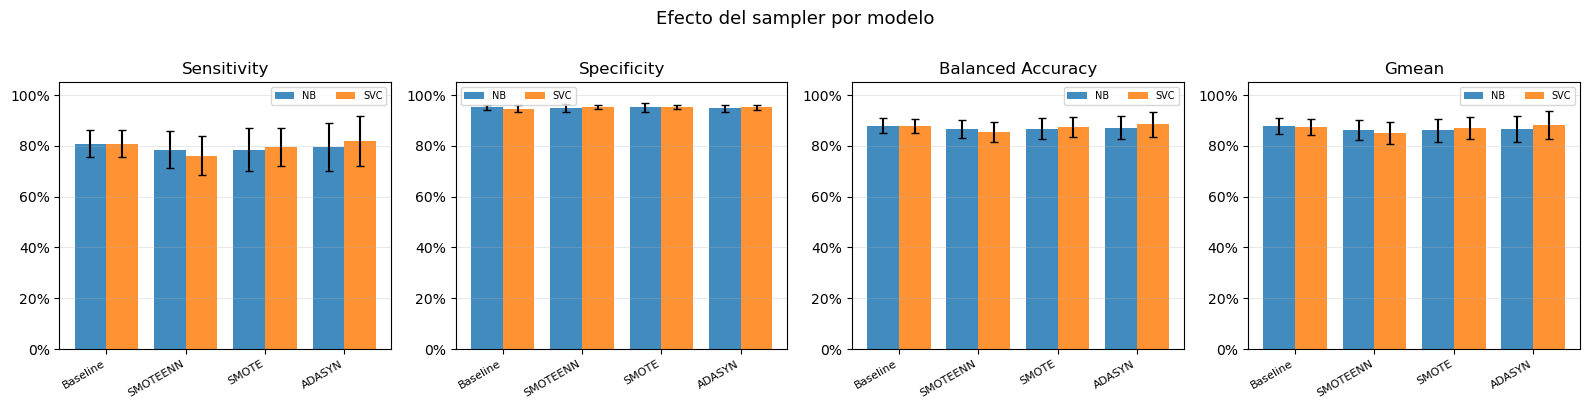

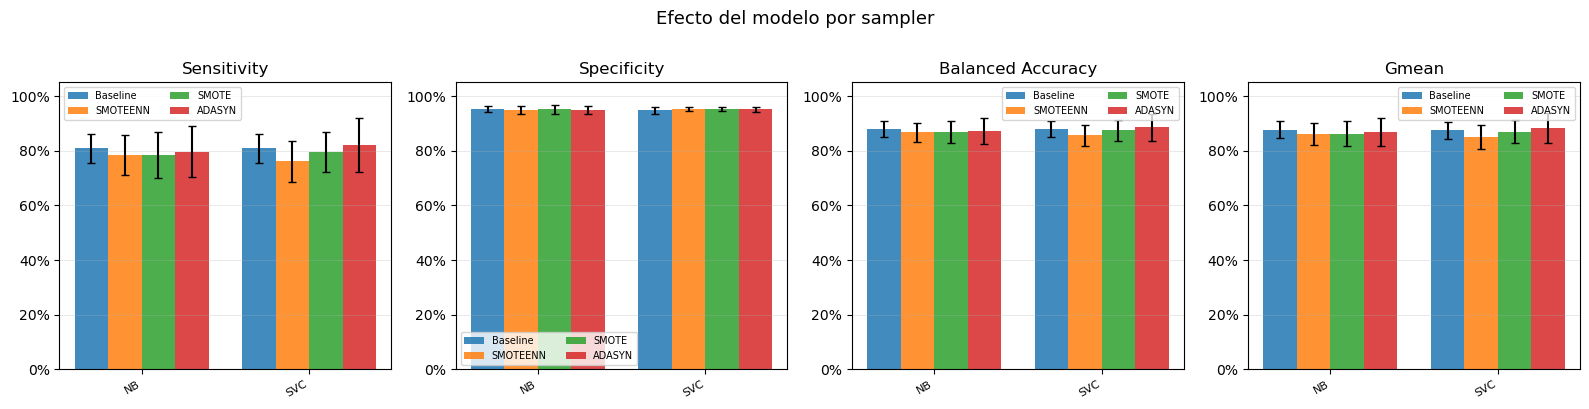

In [7]:
sc.plot_comparison(df_comp)

No elegimos sampler iteramos en más modelos

Models:   0%|          | 0/6 [00:00<?, ?it/s]

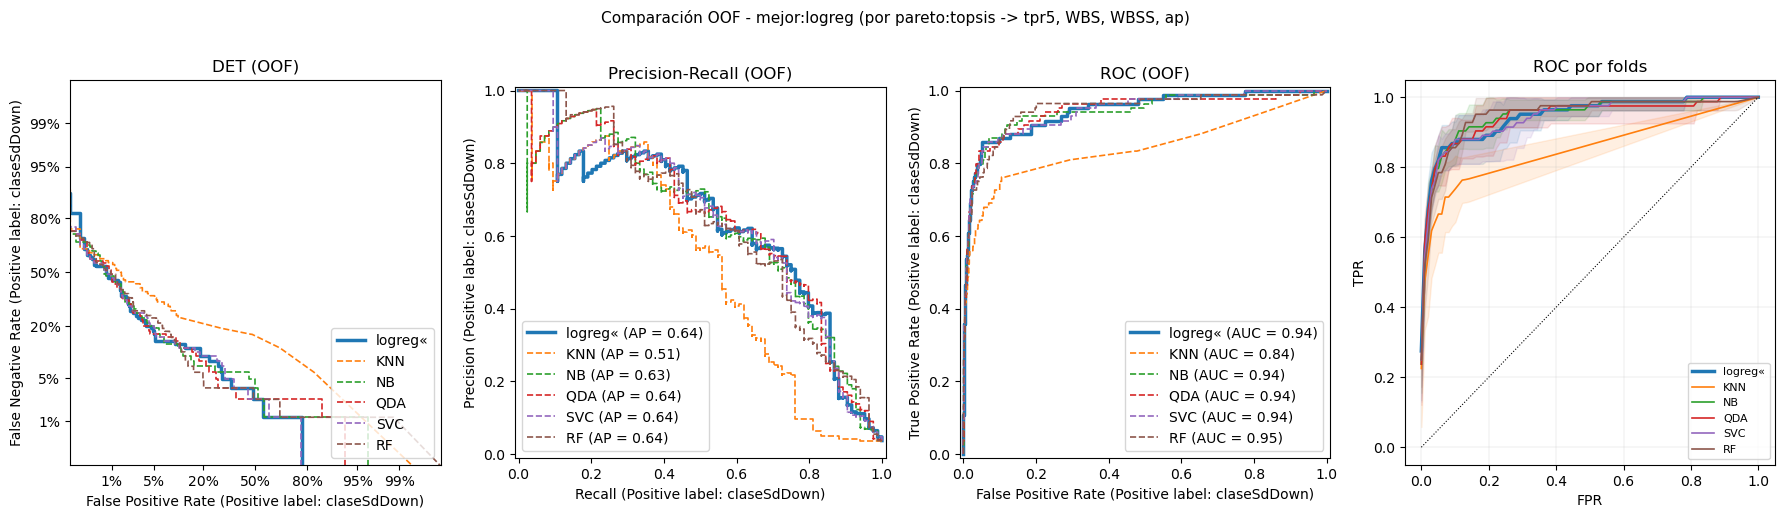


=== Métricas CV - ordenado por pareto:topsis -> tpr5, WBS, WBSS, ap ===
           sensitivity    specificity balanced_accuracy          gmean           tpr5            WBS           WBSS             ap
model                                                                                                                             
logreg«  0.808 ± 0.072  0.952 ± 0.007     0.880 ± 0.038  0.877 ± 0.042  0.820 ± 0.080  0.110 ± 0.014  0.528 ± 0.061  0.661 ± 0.070
KNN      0.413 ± 0.205  0.990 ± 0.009     0.702 ± 0.101  0.620 ± 0.176  0.666 ± 0.123  0.145 ± 0.039  0.375 ± 0.165  0.539 ± 0.160
NB       0.809 ± 0.053  0.951 ± 0.011     0.880 ± 0.030  0.877 ± 0.032  0.796 ± 0.074  0.121 ± 0.017  0.478 ± 0.072  0.654 ± 0.075
QDA      0.820 ± 0.080  0.950 ± 0.005     0.885 ± 0.041  0.882 ± 0.045  0.820 ± 0.080  0.118 ± 0.011  0.493 ± 0.045  0.660 ± 0.074
SVC      0.809 ± 0.053  0.949 ± 0.009     0.879 ± 0.027  0.876 ± 0.029  0.820 ± 0.080  0.113 ± 0.013  0.516 ± 0.053  0.659 ± 0.067
RF       0

In [8]:
# _________ MODELOS Y GRIDS___________
models={"logreg":LogisticRegression(random_state=777),
       "KNN":KNN(weights="distance"),
       "NB":GaussianNB(),
       "QDA":QDA(),
       "SVC":SVC(gamma="scale",probability=True),
       "RF":RF(min_samples_leaf=10)}
param_spaces={
    "logreg": lambda trial: {"C":trial.suggest_float("C",0.01,100,log=True),
                            "l1_ratio":trial.suggest_float("l1_ratio",0.0,1.0)},
    "KNN": lambda trial: {"n_neighbors":trial.suggest_int("n_neighbors",1,60)},
    "NB":None,
    "QDA": lambda trial: {"reg_param":trial.suggest_float("reg_param",0.0,0.9)},
    "SVC": lambda trial: {"C":trial.suggest_float("C",0.001,50,log=True),
                         "kernel":(k:=trial.suggest_categorical("kernel",["rbf","linear","poly","sigmoid"])),
                         **({"gamma": trial.suggest_float("gamma",1e-4,1,log=True)} if k=="rbf" else {})},
    "RF":lambda trial: {"max_depth":trial.suggest_int("max_depth",3,20),
                       "min_samples_leaf":trial.suggest_int("min_samples_leaf",1,20)}
}
T1_eval=CVEvaluator(cv=skf)
df_stats,fitted,name_A=T1_eval.compare_models(models,T1_X_sc,T1_y,grids=param_spaces,sampler=None,
                                             opt_metrics=["tpr5","WBS","WBSS","ap"],pareto_strategy="topsis",
                                             pareto_weights=[2,1,1,1])
best_A=fitted[name_A]

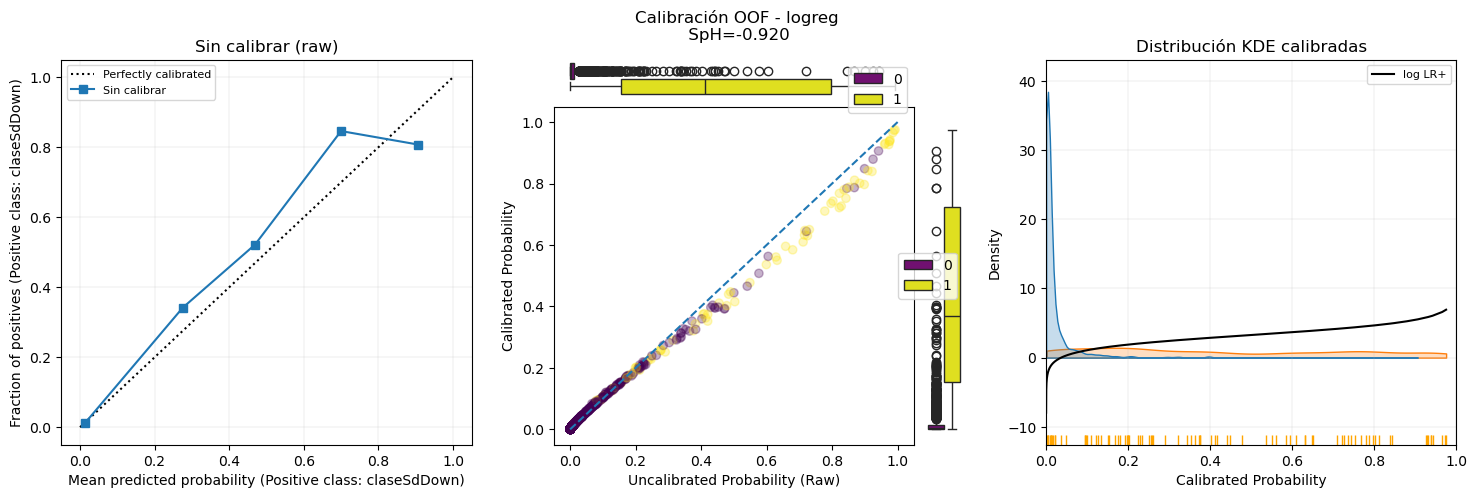

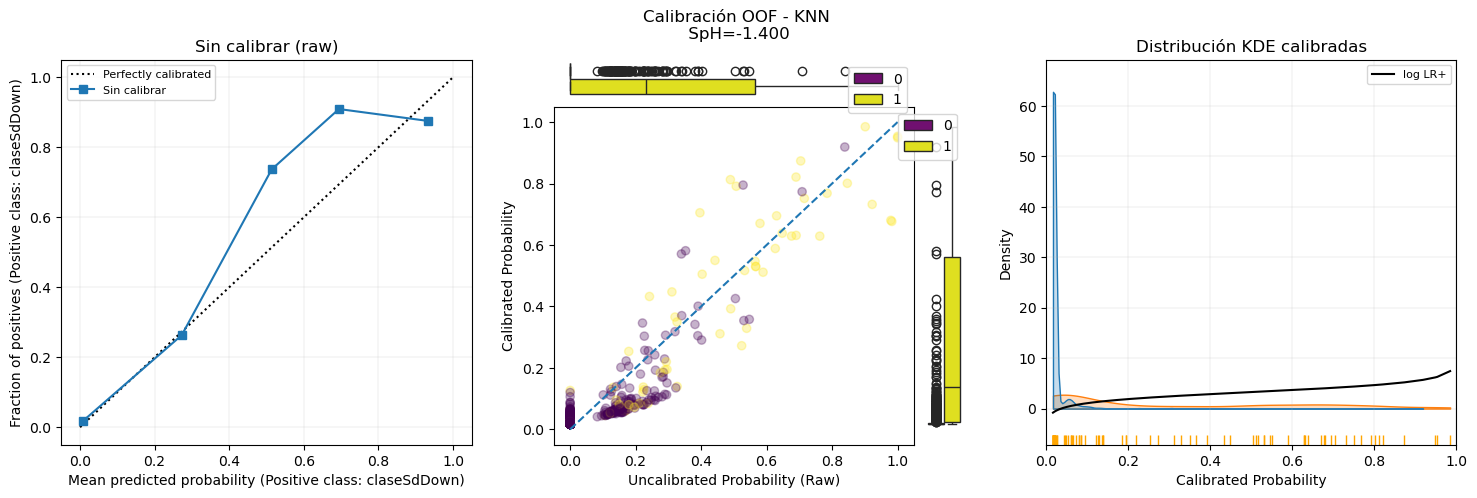

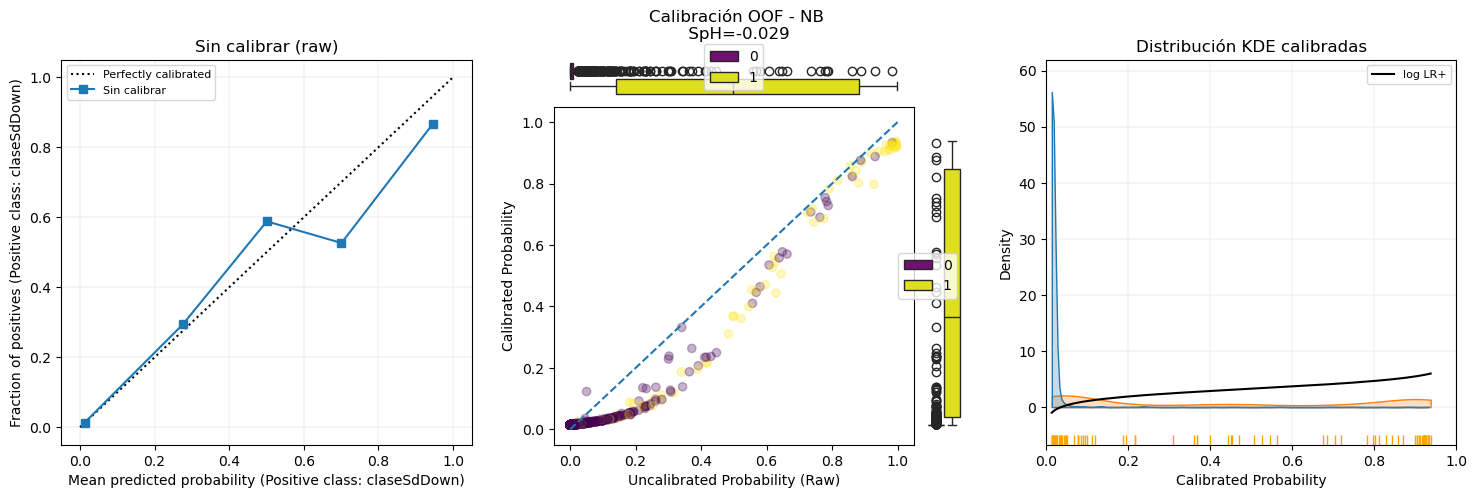

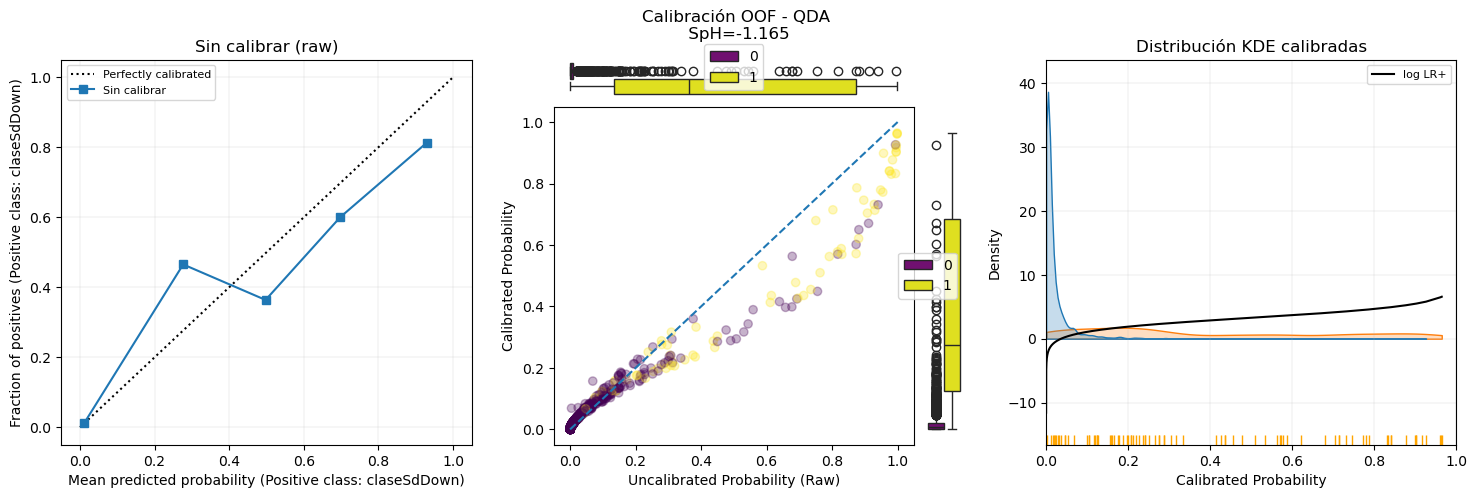

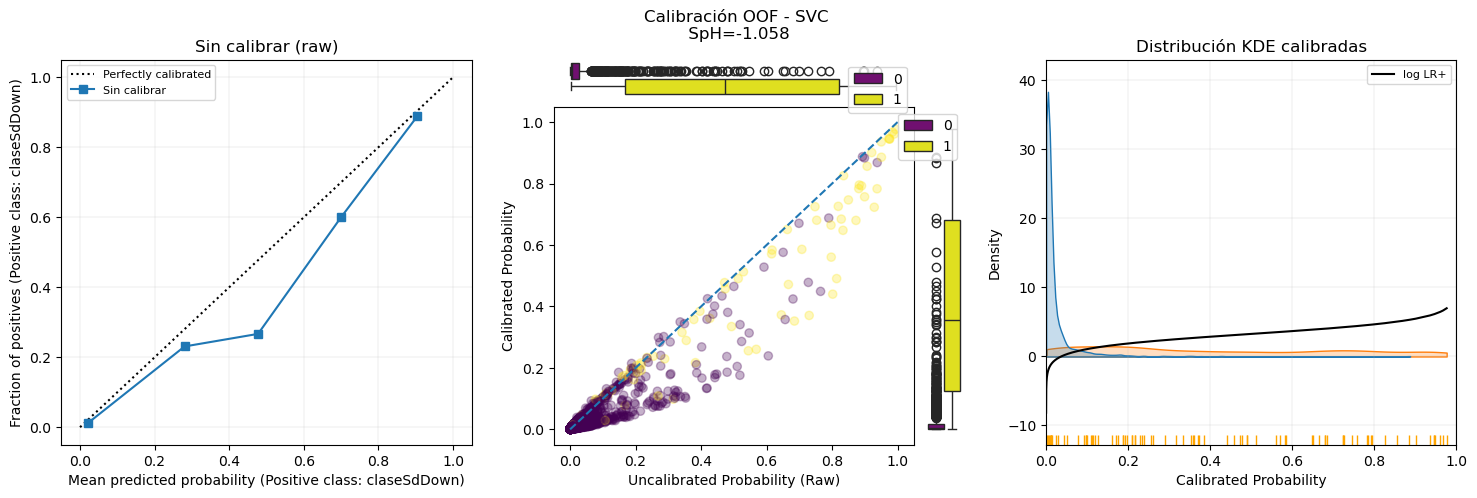

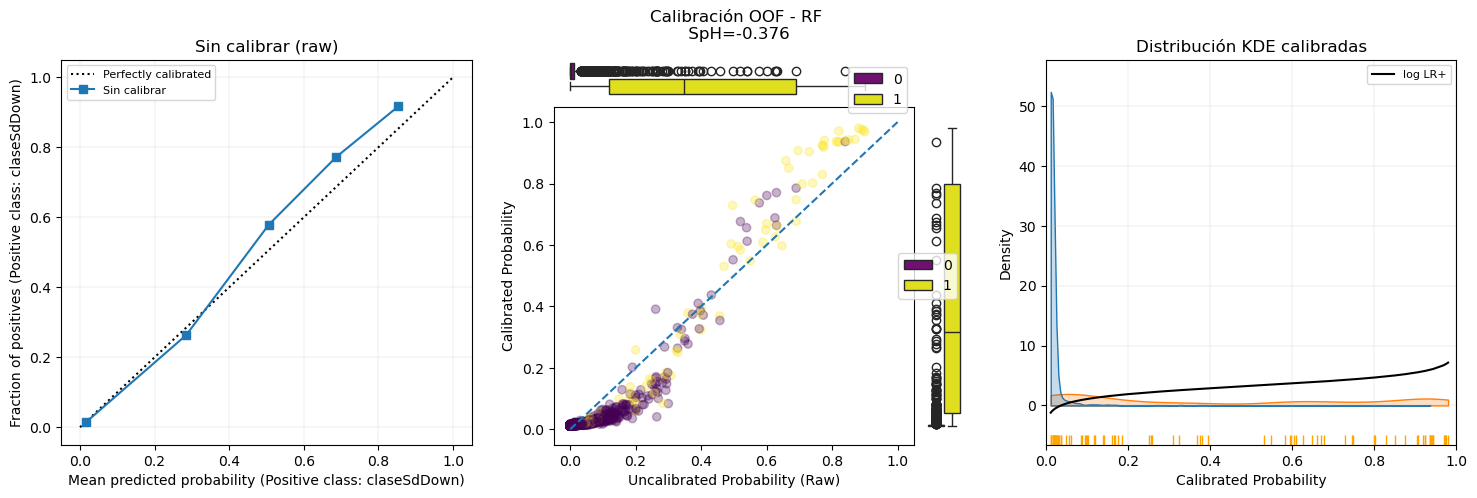

In [9]:
T1_eval.plot_calibration(models,T1_X_sc,T1_y,grids=param_spaces,n_bins=5,
                         pi_train=np.mean(T1_y=="claseSdDown"),pi_real=1/800,
                        opt_metrics=["tpr5","WBS","WBSS","ap"],pareto_strategy="topsis",
                         pareto_weights=[2,1,1,1])

## Partición T2

Models:   0%|          | 0/6 [00:00<?, ?it/s]

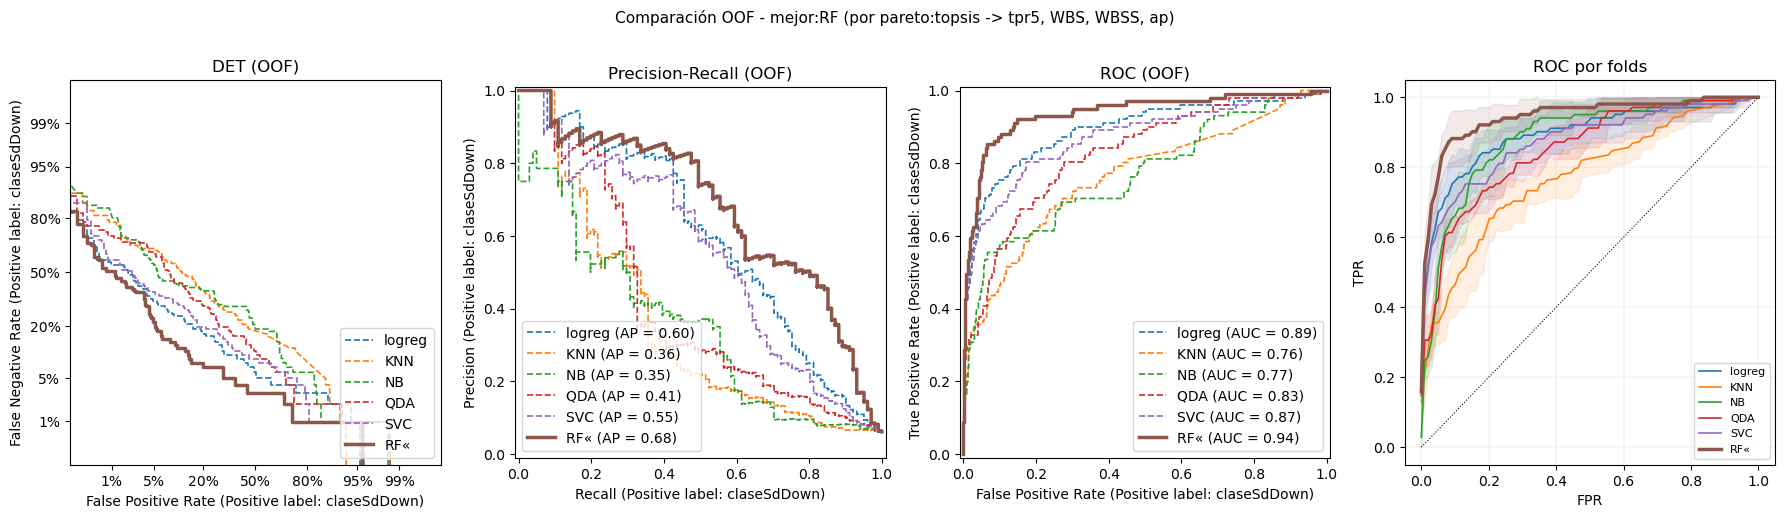


=== Métricas CV - ordenado por pareto:topsis -> tpr5, WBS, WBSS, ap ===
          sensitivity    specificity balanced_accuracy          gmean           tpr5            WBS           WBSS             ap
model                                                                                                                            
logreg  0.673 ± 0.085  0.950 ± 0.012     0.811 ± 0.038  0.798 ± 0.046  0.673 ± 0.085  0.125 ± 0.026  0.436 ± 0.117  0.617 ± 0.078
KNN     0.099 ± 0.035  1.000 ± 0.000     0.550 ± 0.018  0.310 ± 0.058  0.356 ± 0.072  0.183 ± 0.006  0.172 ± 0.029  0.363 ± 0.045
NB      0.553 ± 0.176  0.951 ± 0.018     0.752 ± 0.080  0.718 ± 0.107  0.513 ± 0.124  0.178 ± 0.014  0.195 ± 0.063  0.422 ± 0.034
QDA     0.534 ± 0.092  0.950 ± 0.016     0.742 ± 0.041  0.710 ± 0.059  0.426 ± 0.115  0.166 ± 0.015  0.250 ± 0.067  0.453 ± 0.065
SVC     0.613 ± 0.154  0.951 ± 0.012     0.782 ± 0.071  0.758 ± 0.094  0.633 ± 0.094  0.159 ± 0.020  0.283 ± 0.088  0.565 ± 0.119
RF«     0.605 ± 0

In [10]:

T2_X_sc=preprocessor.fit_transform(T2_X)
#TEST_X_sc=preprocessor.transform(TEST_X)

# _________ MODELOS Y GRIDS___________
models={"logreg":LogisticRegression(random_state=777),
       "KNN":KNN(weights="distance"),
       "NB":GaussianNB(),
       "QDA":QDA(),
       "SVC":SVC(gamma="scale",probability=True),
       "RF":RF(min_samples_leaf=10)}
param_spaces={
    "logreg": lambda trial: {"C":trial.suggest_float("C",0.01,100,log=True),
                            "l1_ratio":trial.suggest_float("l1_ratio",0.0,1.0)},
    "KNN": lambda trial: {"n_neighbors":trial.suggest_int("n_neighbors",1,60)},
    "NB":None,
    "QDA": lambda trial: {"reg_param":trial.suggest_float("reg_param",0.0,0.9)},
    "SVC": lambda trial: {"C":trial.suggest_float("C",0.001,50,log=True),
                         "kernel":(k:=trial.suggest_categorical("kernel",["rbf","linear","poly","sigmoid"])),
                         **({"gamma": trial.suggest_float("gamma",1e-4,1,log=True)} if k=="rbf" else {})},
    "RF":lambda trial: {"max_depth":trial.suggest_int("max_depth",3,20),
                       "min_samples_leaf":trial.suggest_int("min_samples_leaf",1,20)}
}
T2_eval=CVEvaluator(cv=skf)
df_stats,fitted,name_B=T2_eval.compare_models(models,T2_X_sc,T2_y,grids=param_spaces,sampler=None,
                                             opt_metrics=["tpr5","WBS","WBSS","ap"],pareto_strategy="topsis",
                                             pareto_weights=[2,1,1,1])
best_B=fitted[name_B]

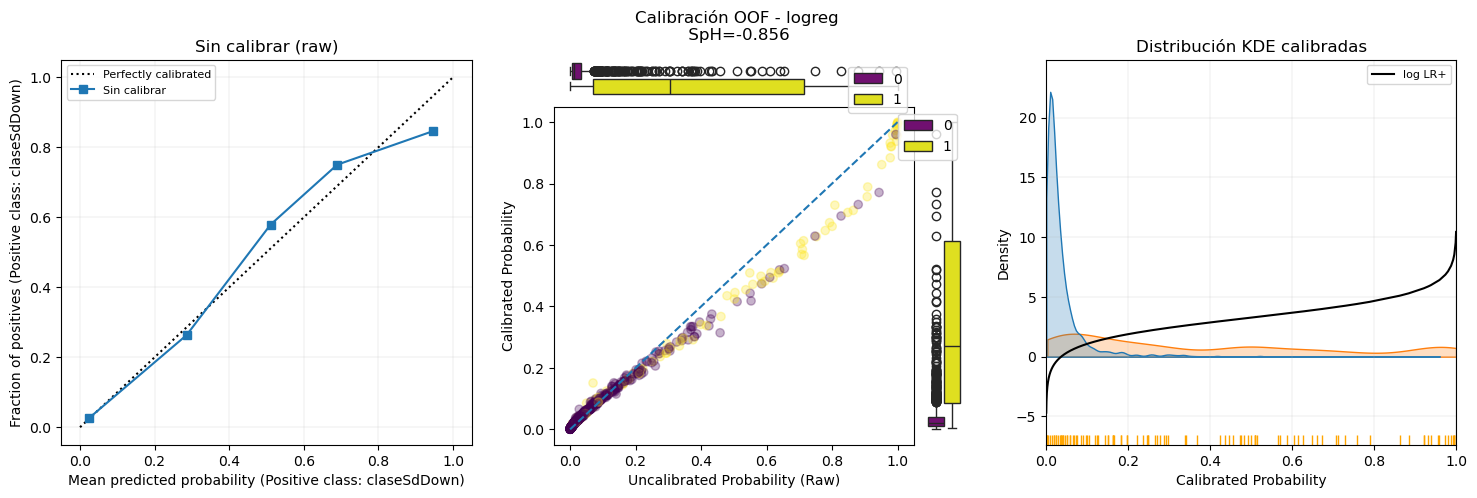

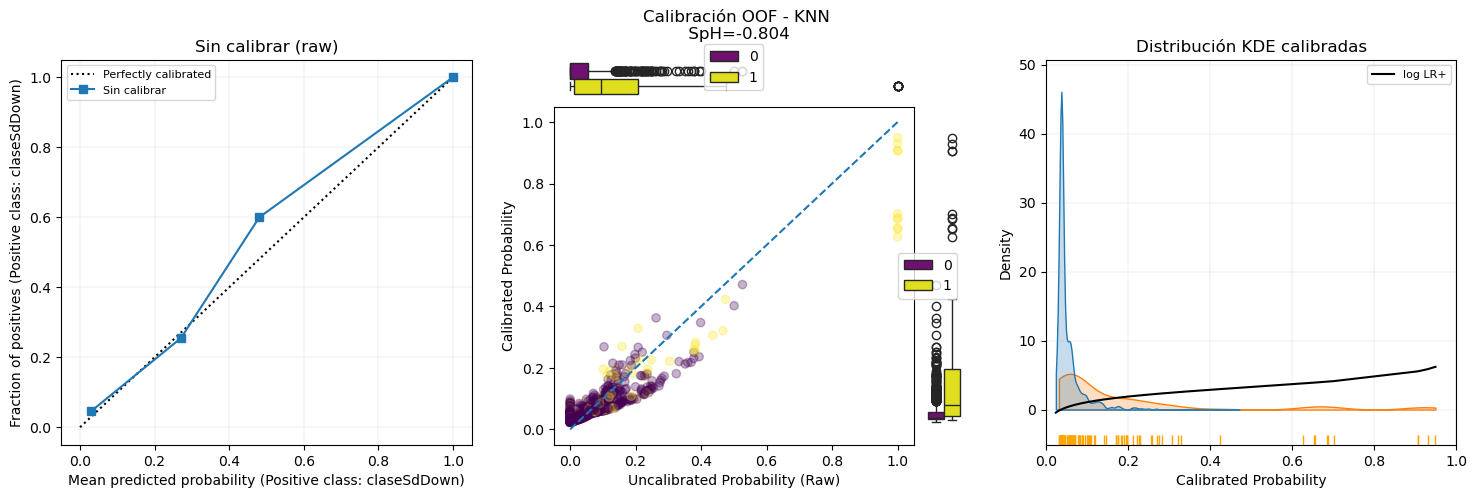

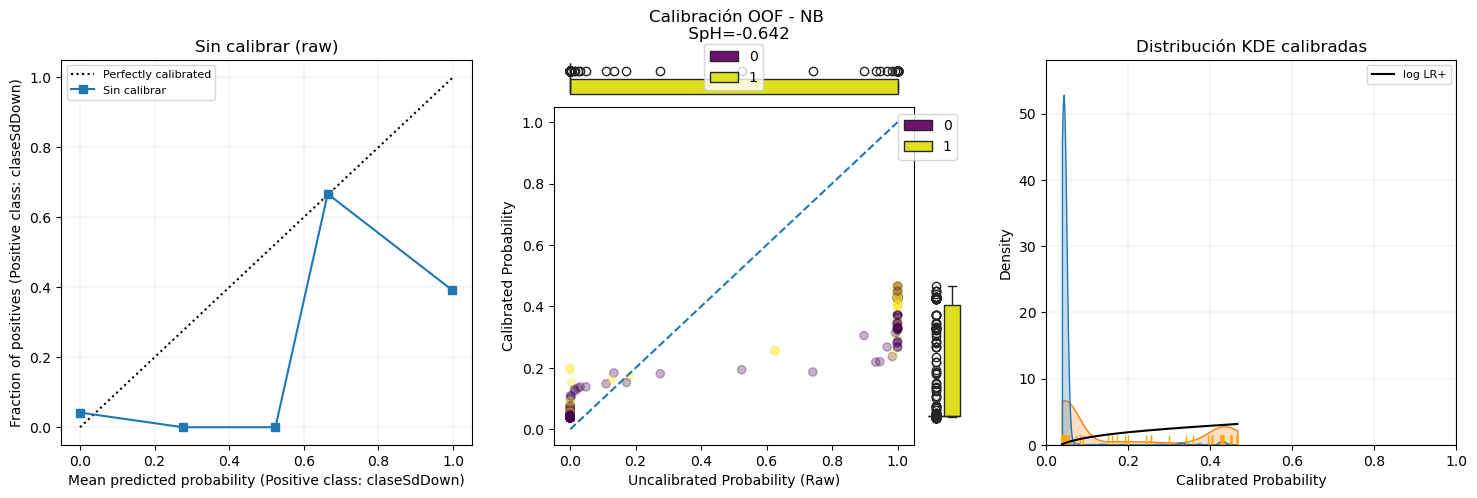

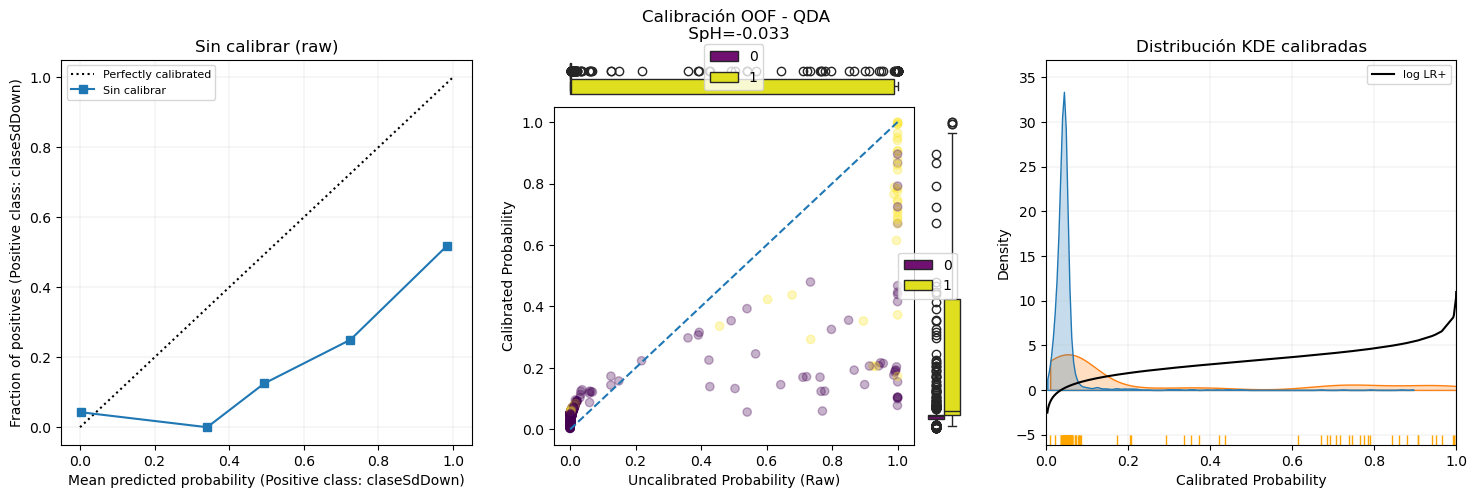

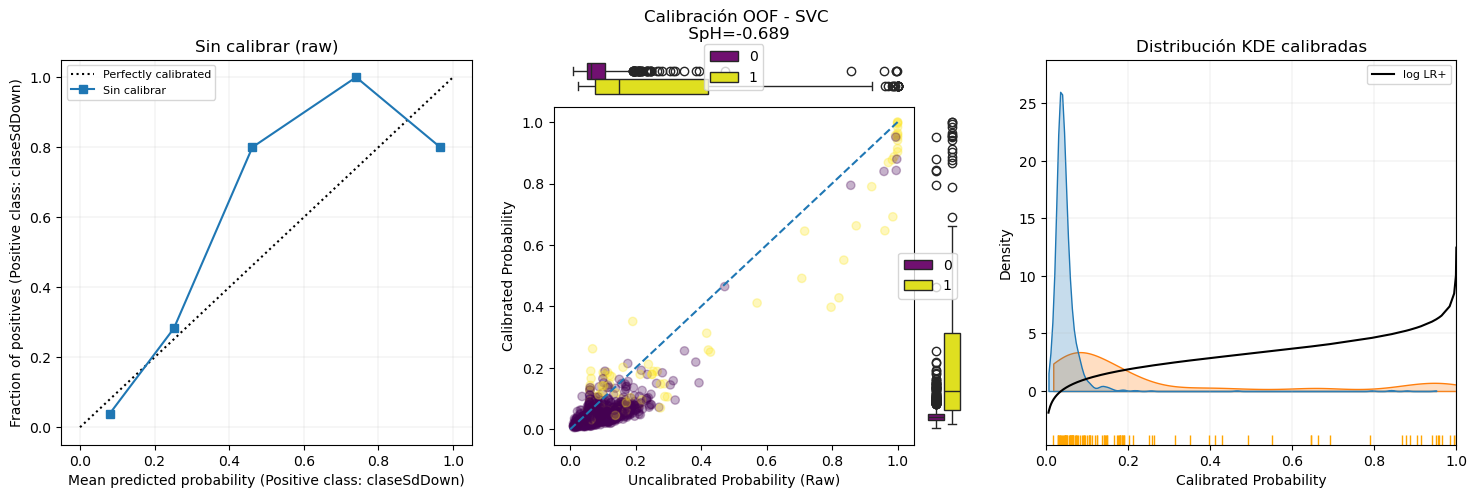

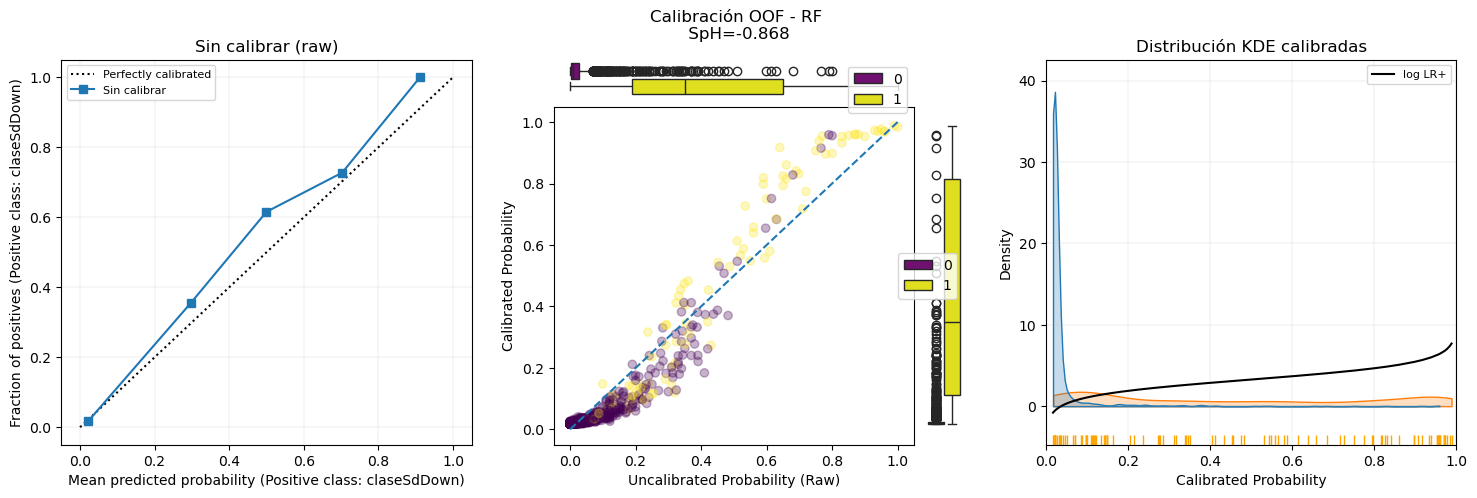

In [11]:
T2_eval.plot_calibration(models,T2_X_sc,T2_y,grids=param_spaces,n_bins=5,
                         pi_train=np.mean(T1_y=="claseSdDown"),pi_real=1/800,
                        opt_metrics=["tpr5","WBS","WBSS","ap"],pareto_strategy="topsis",
                         pareto_weights=[2,1,1,1])

## Partición T1 & T2

In [41]:
#preprocessor.transform(pd.DataFrame({"EDADmaterna":[33]}))
a=T12_X_sc.iloc[0:1,].copy()
a["EDADmadre"]=1
a["TALLAmadre"]=0
a["PESOmadre"]=6
preprocessor.named_transformers_["standard"].inverse_transform(a.loc[:,["EDADmadre","TALLAmadre","PESOmadre"]])


array([[ 37.89366508, 163.14963145, 145.55676039]])

Models:   0%|          | 0/6 [00:00<?, ?it/s]

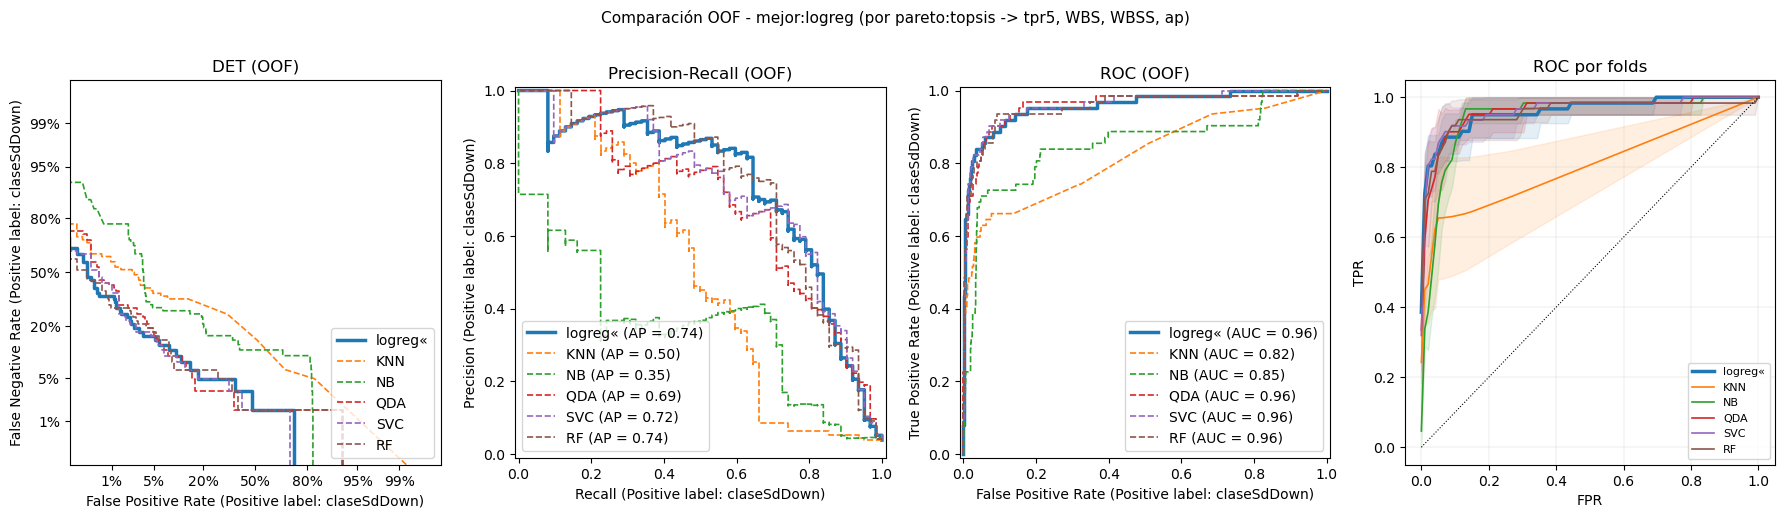


=== Métricas CV - ordenado por pareto:topsis -> tpr5, WBS, WBSS, ap ===
           sensitivity    specificity balanced_accuracy          gmean           tpr5            WBS           WBSS             ap
model                                                                                                                             
logreg«  0.853 ± 0.073  0.950 ± 0.008     0.901 ± 0.035  0.899 ± 0.038  0.837 ± 0.061  0.091 ± 0.039  0.608 ± 0.167  0.767 ± 0.076
KNN      0.341 ± 0.176  0.993 ± 0.007     0.667 ± 0.089  0.560 ± 0.178  0.655 ± 0.195  0.152 ± 0.025  0.344 ± 0.106  0.495 ± 0.132
NB       0.724 ± 0.188  0.951 ± 0.019     0.838 ± 0.088  0.824 ± 0.103  0.695 ± 0.206  0.173 ± 0.015  0.254 ± 0.064  0.475 ± 0.085
QDA      0.835 ± 0.157  0.948 ± 0.012     0.891 ± 0.076  0.886 ± 0.085  0.836 ± 0.146  0.112 ± 0.042  0.516 ± 0.180  0.702 ± 0.161
SVC      0.869 ± 0.077  0.950 ± 0.006     0.909 ± 0.040  0.908 ± 0.042  0.869 ± 0.077  0.099 ± 0.040  0.571 ± 0.171  0.753 ± 0.085
RF       0

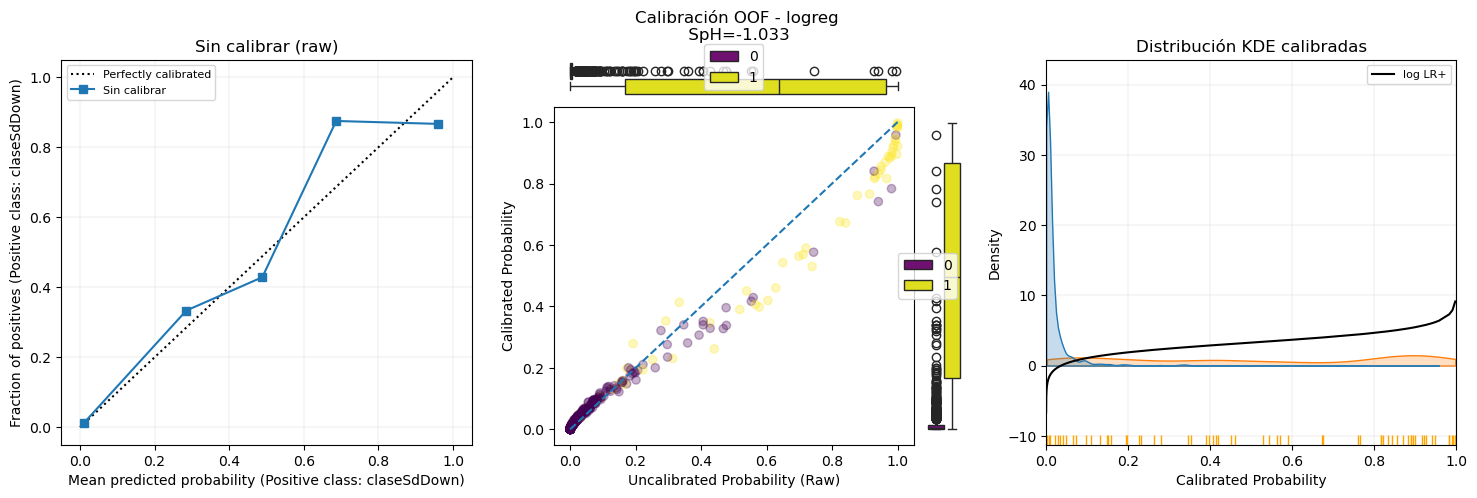

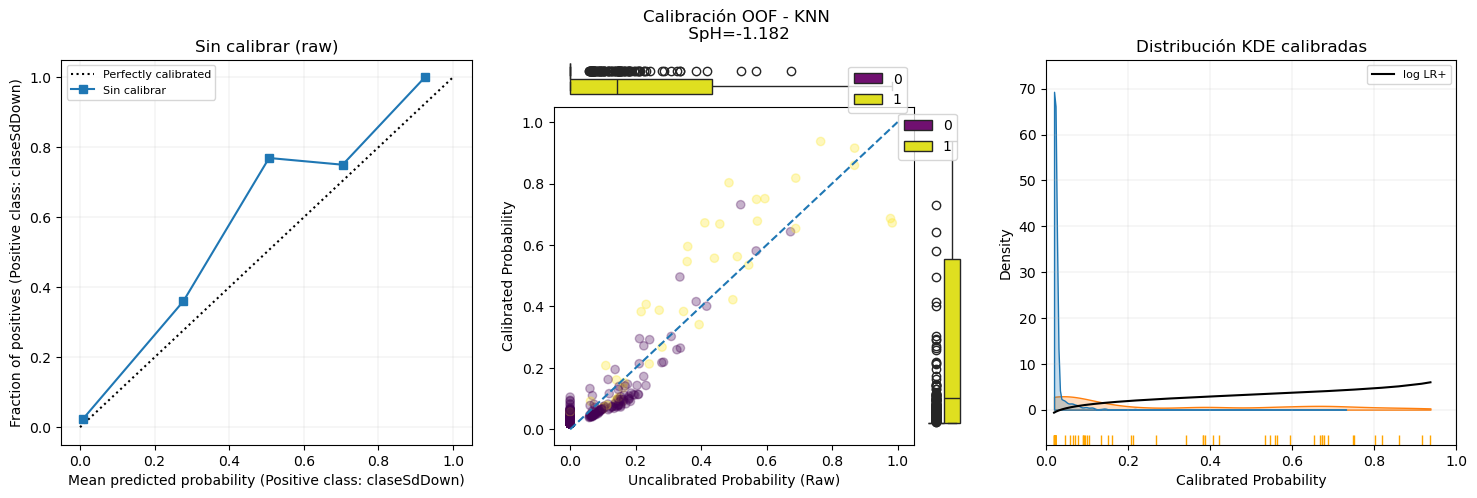

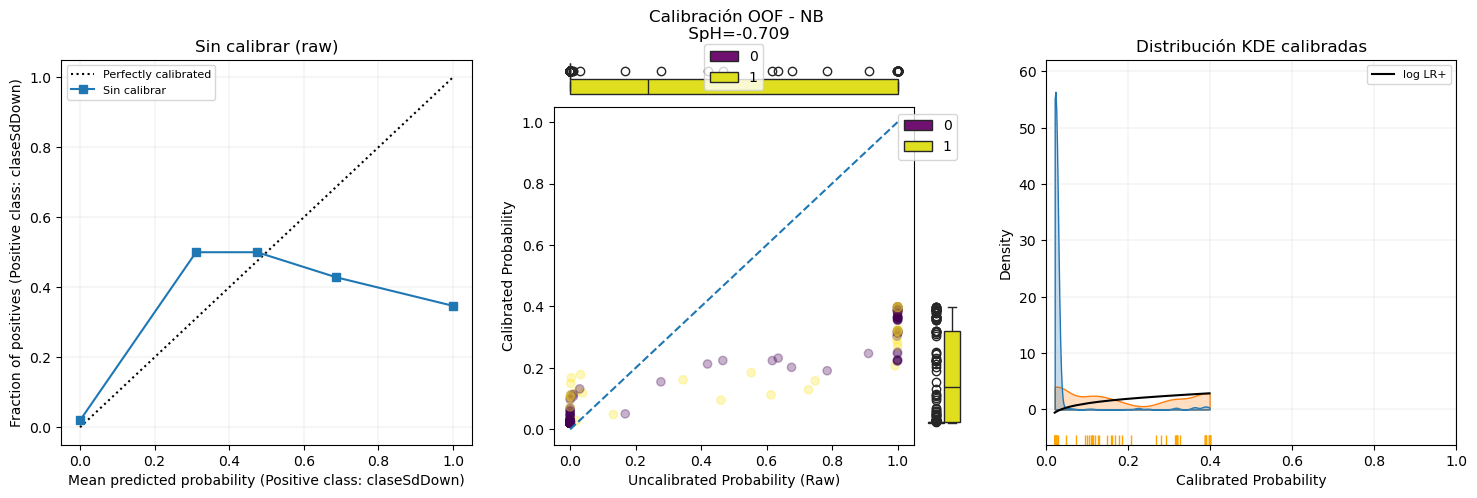

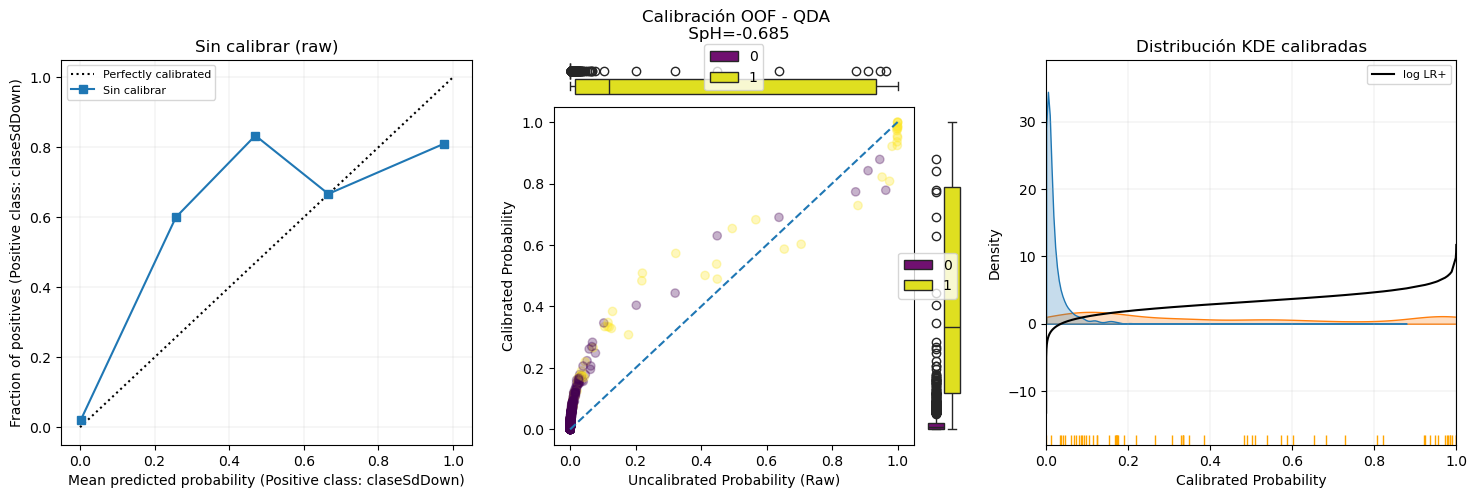

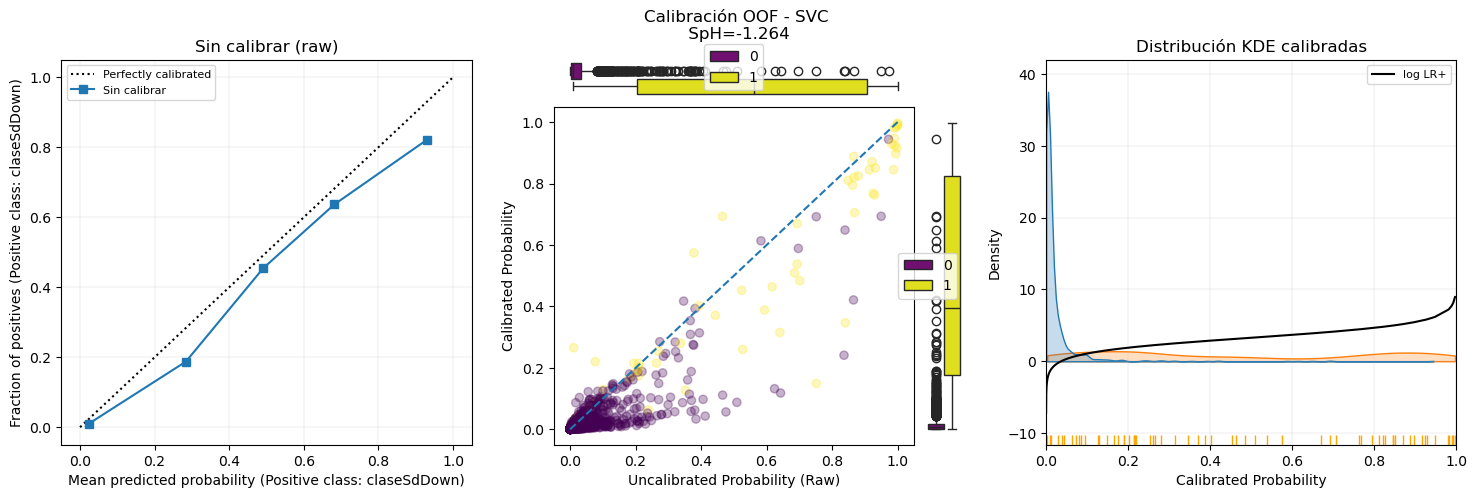

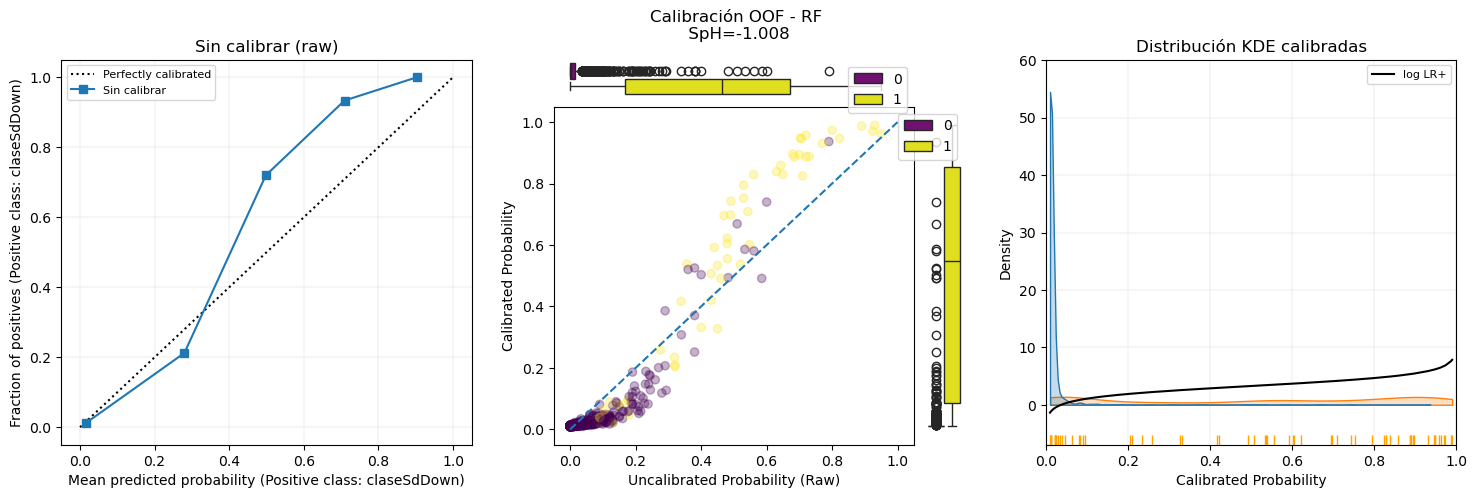

In [5]:
T12_X=T1.join(T2,how="inner").join(Madre.drop(columns="CLASE"),how="left")
T12_X_sc=preprocessor.fit_transform(T12_X)
TEST_X_sc=preprocessor.transform(TEST_X)
T12_y=Madre.loc[T12_X.index,"CLASE"]

models={"logreg":LogisticRegression(random_state=777),
       "KNN":KNN(weights="distance"),
       "NB":GaussianNB(),
       "QDA":QDA(),
       "SVC":SVC(gamma="scale",probability=True),
       "RF":RF(min_samples_leaf=10)}
param_spaces={
    "logreg": lambda trial: {"C":trial.suggest_float("C",0.01,100,log=True),
                            "l1_ratio":trial.suggest_float("l1_ratio",0.0,1.0)},
    "KNN": lambda trial: {"n_neighbors":trial.suggest_int("n_neighbors",1,60)},
    "NB":None,
    "QDA": lambda trial: {"reg_param":trial.suggest_float("reg_param",0.0,0.9)},
    "SVC": lambda trial: {"C":trial.suggest_float("C",0.001,50,log=True),
                         "kernel":(k:=trial.suggest_categorical("kernel",["rbf","linear","poly","sigmoid"])),
                         **({"gamma": trial.suggest_float("gamma",1e-4,1,log=True)} if k=="rbf" else {})},
    "RF":lambda trial: {"max_depth":trial.suggest_int("max_depth",3,20),
                       "min_samples_leaf":trial.suggest_int("min_samples_leaf",1,20)}
}
T12_eval=CVEvaluator(cv=skf)
df_stats,fitted,name_AB=T12_eval.compare_models(models,T12_X_sc,T12_y,grids=param_spaces,sampler=None,
                                             opt_metrics=["tpr5","WBS","WBSS","ap"],pareto_strategy="topsis",
                                             pareto_weights=[2,1,1,1])
best_AB=fitted[name_AB]


T12_eval.plot_calibration(models,T12_X_sc,T12_y,grids=param_spaces,n_bins=5,
                         pi_train=np.mean(T1_y=="claseSdDown"),pi_real=1/800,
                        opt_metrics=["tpr5","WBS","WBSS","ap"],pareto_strategy="topsis",
                         pareto_weights=[1,1,1,1])

## Modular

In [25]:
stack_cache_tag="opt_tpr5-WBS-WBSS-ap__pareto_topsis"
scores_12=stack_oof_scores(T1_eval,name_A,T1_y,T2_eval,name_B,T2_y,
                           cache_tag_contains=stack_cache_tag)
y_stack=(T12_y=="claseSdDown").astype(int)

logit=LogisticRegression(random_state=777,max_iter=2000)#class_weight="balanced"
logit.fit(scores_12,y_stack)
u_STACK=T12_eval._threshold_at_fpr(T12_y,logit.predict_proba(scores_12)[:,1])
S=STACK(best_A,best_B,logit,name=f"STACK({name_A}+{name_B})")
S.fit(T12_X_sc,T12_y) #No ajusta

meta_passthrough=pd.concat([scores_12,T12_X_sc],axis=1)
logit_passthrough=LogisticRegression(random_state=777,max_iter=2000)
logit_passthrough.fit(meta_passthrough,y_stack)
u_STACK_PT=T12_eval._threshold_at_fpr(T12_y,
                                   logit_passthrough.predict_proba(meta_passthrough)[:,1])
S_passthrough=STACK(best_A,best_B,logit_passthrough,passthrough=True,
                    name=f"STACK+PT({name_A}+{name_B})")
S_passthrough.fit(T12_X_sc,T12_y) #No ajusta

u_AB=T12_eval._threshold_at_fpr(T12_y,best_AB.predict_proba(T12_X_sc)[:,1])

In [29]:
u_STACK_PT

np.float64(0.06117342453579007)

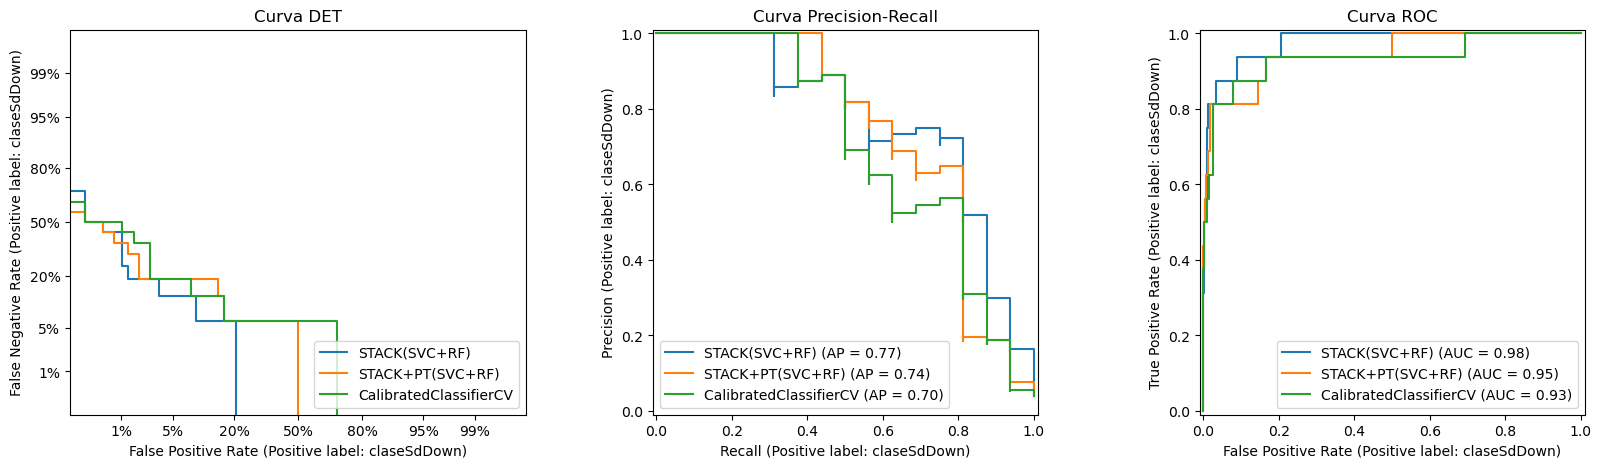

STACK(SVC+RF)
_____________________________________________________________________________________
sup_neg: 392  sup_pos: 16  prev: 0.039
sens: 0.875 [0.692, 1.000]
spec: 0.954 [0.932, 0.974]
gmean: 0.914 [0.813, 0.982]
tpr5: 0.812 [0.684, 1.000]
WBSS:  0.481 [0.276, 0.688]
AP:   0.771 [0.560, 0.933]
LR+:  19.056 [12.250, 33.478]
LR-:  0.131 [0.000, 0.321]

STACK+PT(SVC+RF)
_____________________________________________________________________________________
sup_neg: 392  sup_pos: 16  prev: 0.039
sens: 0.812 [0.615, 1.000]
spec: 0.946 [0.924, 0.967]
gmean: 0.877 [0.762, 0.974]
tpr5: 0.688 [0.615, 1.000]
WBSS:  0.561 [0.362, 0.756]
AP:   0.744 [0.537, 0.915]
LR+:  15.167 [9.827, 26.250]
LR-:  0.198 [0.000, 0.407]

CalibratedClassifierCV
_____________________________________________________________________________________
sup_neg: 392  sup_pos: 16  prev: 0.039
sens: 0.812 [0.615, 1.000]
spec: 0.946 [0.924, 0.967]
gmean: 0.877 [0.761, 0.974]
tpr5: 0.625 [0.600, 1.000]
WBSS:  0.542 [0.357

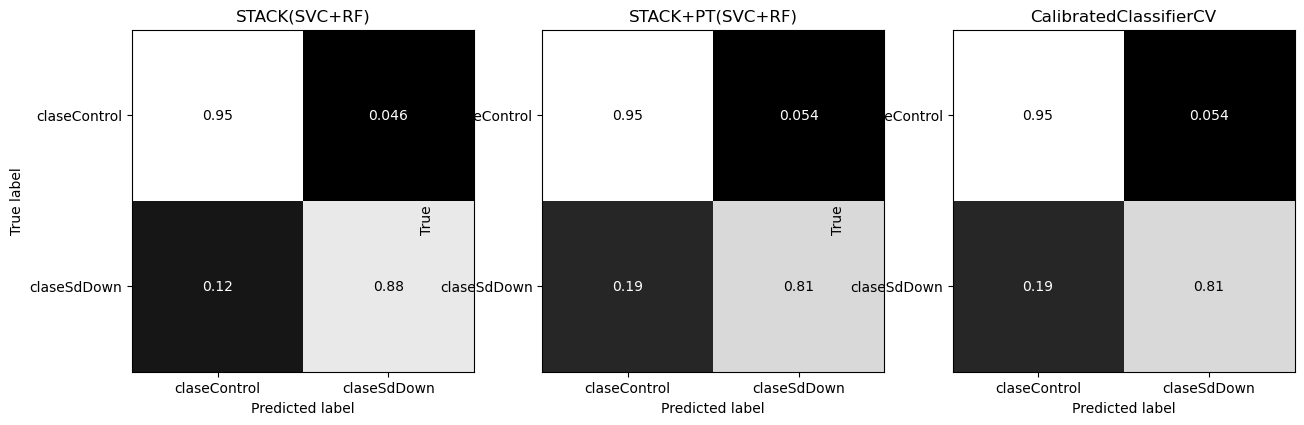

In [26]:
a=ModelReport()
a.evaluate([S,S_passthrough,best_AB],TEST_X_sc,TEST_y,thresholds=[u_STACK,u_STACK_PT,u_AB])

In [23]:
import joblib

joblib.dump(best_A,'./Modelos/best_1T.joblib')
joblib.dump(best_B,'./Modelos/best_2T.joblib')
joblib.dump(best_AB,'./Modelos/best_12T.joblib')
joblib.dump(S,'./Modelos/STACK.joblib')
joblib.dump(S_passthrough,'./Modelos/STACK_pt.joblib')

['./Modelos/STACK_pt.joblib']